In [2]:
from calendar import prweek

import pandas as pd
import numpy as np

In [147]:
patient_info = pd.read_csv('/home/simon/Data/Augsburg_large/patient_info.csv', index_col=[0])
results = pd.read_excel('/home/simon/Data/Augsburg_large/results.xlsx', index_col=[0, 1])

# Data exploration

In [148]:
patient_info.head()

,Age,Sex
Patient,,
PA000291,16.0,F
PA000464,13.0,F
PA000654,13.0,F
PA000926,9.0,M
PA000154,15.0,M


In [149]:
results.head()

CCD (actual)  CCD (projected)   AT (Lee)  AT (Murphy)  \
Patient  Side                                                           
PA000291 right    136.780084       150.458997  11.556465    44.530373   
         left     111.691209       115.309648   7.323683    19.777573   
PA000464 right           NaN              NaN        NaN          NaN   
         left     110.662322       130.854774        NaN    76.443208   
PA000654 right    102.797367        99.197674 -13.766234     0.206099   

                       TT         KRA          LL  
Patient  Side                                      
PA000291 right  31.976600  171.068847  843.462136  
         left   46.061608    4.107275  846.165378  
PA000464 right  28.586362  168.994233  865.933814  
         left   45.870811   10.784298  858.211956  
PA000654 right  33.564101    7.144485  772.227323

In [150]:
combined = results.join(patient_info)

In [151]:
combined.head()

CCD (actual)  CCD (projected)   AT (Lee)  AT (Murphy)  \
Patient  Side                                                           
PA000291 right    136.780084       150.458997  11.556465    44.530373   
         left     111.691209       115.309648   7.323683    19.777573   
PA000464 right           NaN              NaN        NaN          NaN   
         left     110.662322       130.854774        NaN    76.443208   
PA000654 right    102.797367        99.197674 -13.766234     0.206099   

                       TT         KRA          LL   Age Sex  
Patient  Side                                                
PA000291 right  31.976600  171.068847  843.462136  16.0   F  
         left   46.061608    4.107275  846.165378  16.0   F  
PA000464 right  28.586362  168.994233  865.933814  13.0   F  
         left   45.870811   10.784298  858.211956  13.0   F  
PA000654 right  33.564101    7.144485  772.227323  13.0   F

In [152]:
combined.describe()

,CCD (actual),CCD (projected),AT (Lee),AT (Murphy),TT,KRA,LL,Age
count,1777.000000,1777.000000,1655.000000,1782.000000,1599.000000,1603.000000,1899.000000,1902.000000
mean,119.106533,130.364903,6.418613,24.799133,36.118028,37.452514,811.523435,15.766562
std,19.698203,20.760251,14.214564,19.061154,12.152912,66.577371,84.783133,7.414402
min,90.054008,90.048083,-31.302095,-51.842773,-86.611614,0.000000,451.724560,6.000000
25%,102.799025,115.184082,-3.871710,13.213462,29.838278,2.641822,761.512707,12.000000
50%,116.099873,131.758532,6.001714,24.220157,36.497564,5.859017,816.301406,14.000000
75%,130.695717,143.623000,16.412161,35.577992,43.179604,11.549356,865.619690,16.000000
max,175.402983,179.994180,71.176564,172.247667,94.781721,180.000000,1046.532864,64.000000


In [153]:
combined['Sex'].value_counts()

Sex
M    980
F    920
O      2
Name: count, dtype: int64

Remove 'other'...

In [154]:
from matplotlib import pyplot as plt

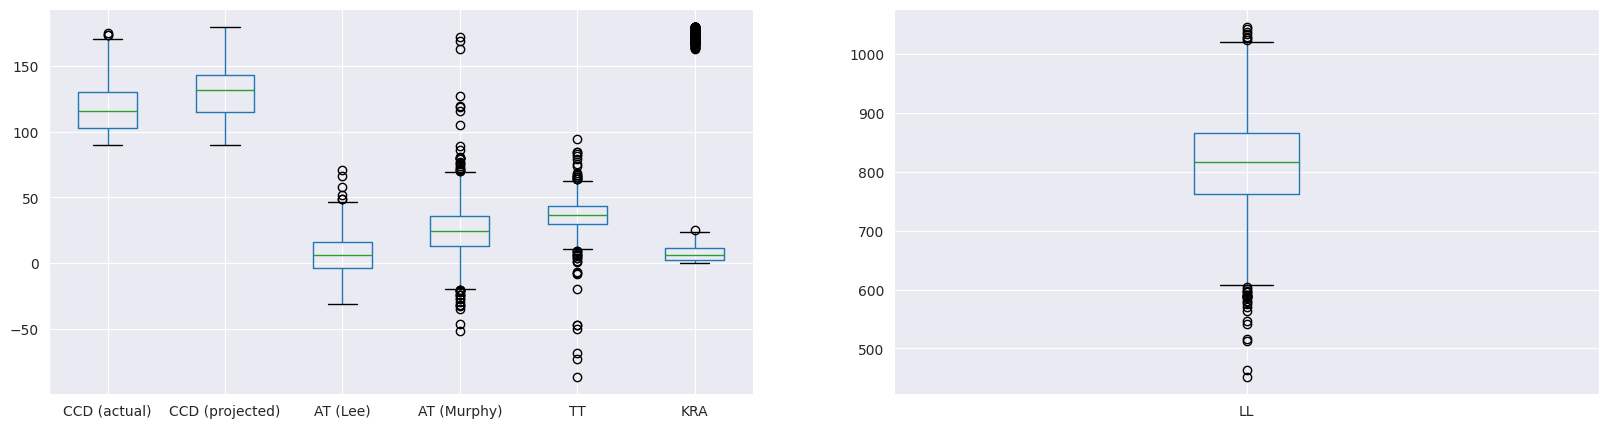

In [155]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
ax[0] = combined.boxplot(column=['CCD (actual)', 'CCD (projected)', 'AT (Lee)', 'AT (Murphy)', 'TT', 'KRA'], ax=ax[0])
ax[1] = combined.boxplot(column=['LL'], ax=ax[1])
plt.show()


Remove all KRA > 100...

# Data preprocessing

In [156]:
combined.drop(combined[combined['Sex'] == 'O'].index, inplace=True)

## Outlier removal

In [157]:
def set_outliers_to_nan(column):
    mean = column.mean()
    std = column.std()
    return column.apply(lambda x: np.nan if abs(x - mean) > 2 * std else x)

In [158]:
combined[['CCD (actual)', 'CCD (projected)', 'AT (Lee)', 'AT (Murphy)', 'TT', 'KRA']] = combined[['CCD (actual)', 'CCD (projected)', 'AT (Lee)', 'AT (Murphy)', 'TT', 'KRA']].apply(set_outliers_to_nan)  # exclude leg length because it seems robust to outliers

In [159]:
combined['KRA'] = combined['KRA'].apply(lambda x: np.nan if x > 100 else x)

In [160]:
combined.describe()

,CCD (actual),CCD (projected),AT (Lee),AT (Murphy),TT,KRA,LL,Age
count,1691.000000,1737.000000,1581.000000,1707.000000,1551.000000,1297.000000,1897.000000,1900.000000
mean,116.929723,129.368675,6.038970,24.445417,36.396880,5.285688,811.435819,15.766316
std,17.535521,19.852274,12.572618,15.203146,9.031831,3.941068,84.784743,7.418302
min,90.054008,90.048083,-21.628398,-13.307387,12.443340,0.000000,451.724560,6.000000
25%,102.278315,114.871878,-3.757579,13.694263,30.078805,2.201002,761.353733,12.000000
50%,114.592249,131.162624,5.837610,24.208268,36.502010,4.398705,816.286935,14.000000
75%,128.527909,142.726331,15.696980,34.992020,42.961291,7.670580,865.481962,16.000000
max,158.446307,171.737664,34.542246,62.887554,60.158010,23.719306,1046.532864,64.000000


# AT as function of age

In [16]:
from sklearn import linear_model

In [17]:
X = combined[['AT (Lee)', 'AT (Murphy)', 'Age']].copy()
X = X.dropna()
Y_1 = X['AT (Lee)']
Y_2 = X['AT (Murphy)']
X = X['Age'].to_numpy().reshape(-1, 1)

In [18]:
reg_1 = linear_model.LinearRegression()
reg_1.fit(X, Y_1)
reg_1.coef_

array([-0.02509773])

In [19]:
reg_2 = linear_model.LinearRegression()
reg_2.fit(X, Y_2)
reg_2.coef_

array([0.16394159])

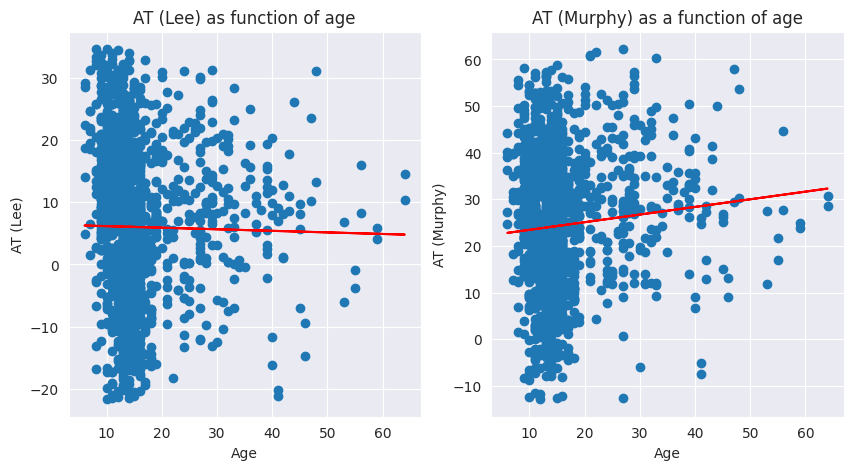

In [21]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=False)
ax[0].scatter(X, Y_1)
ax[0].plot(X, reg_1.predict(X), 'r')
ax[0].set(title='AT (Lee) as function of age', xlabel='Age', ylabel='AT (Lee)')
ax[1].scatter(X, Y_2)
ax[1].plot(X, reg_2.predict(X), 'r')
ax[1].set(title='AT (Murphy) as a function of age', xlabel='Age', ylabel='AT (Murphy)')
plt.show()

# AT as function of sex

In [22]:
data = combined[['AT (Lee)', 'AT (Murphy)', 'Sex']].copy()
data = data.dropna()

In [23]:
import seaborn as sns

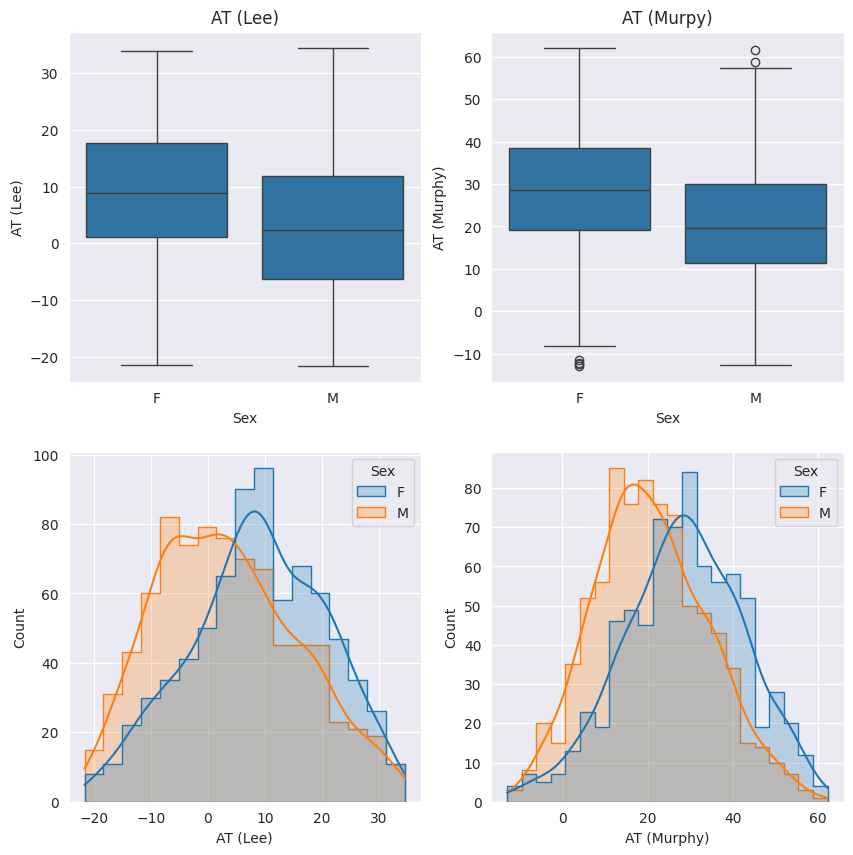

In [24]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
sns.boxplot(x='Sex', y='AT (Lee)', data=data, ax=ax[0, 0])
ax[0][0].set(title='AT (Lee)')
sns.boxplot(x='Sex', y='AT (Murphy)', data=data, ax=ax[0, 1])
ax[0][1].set(title='AT (Murpy)')
sns.histplot(x='AT (Lee)', hue='Sex', kde=True, element='step', data=data, ax=ax[1, 0])
sns.histplot(x='AT (Murphy)', hue='Sex', kde=True, element='step', data=data, ax=ax[1, 1])
plt.show()


In [25]:
from scipy import stats

In [26]:
from sklearn.preprocessing import LabelBinarizer

In [27]:
lb = LabelBinarizer()
lb.fit(data['Sex'])

LabelBinarizer()

In [28]:
labels = lb.transform(data['Sex'])

In [29]:
pd.DataFrame(data={'Sex': data['Sex'], 'Label': labels.T[0]})

Sex  Label
Patient  Side            
PA000291 right   F      0
         left    F      0
PA000654 right   F      0
         left    F      0
PA000926 right   M      1
...             ..    ...
PA001031 left    F      0
PA000807 right   F      0
         left    F      0
PA000227 right   M      1
         left    M      1

[1559 rows x 2 columns]

In [30]:
stats.pointbiserialr(labels.T[0], data['AT (Lee)'].to_numpy())  # wtf numpy

SignificanceResult(statistic=-0.21385044273846068, pvalue=1.391095959580247e-17)

In [31]:
stats.pointbiserialr(labels.T[0], data['AT (Murphy)'].to_numpy())  # wtf numpy

SignificanceResult(statistic=-0.26867781193204365, pvalue=3.4727074421105725e-27)

**Interpretation:** Male is encoded 1 and Female is encoded 0, so a negative correlation means that the AT is higher for females

## Normality testing

In [32]:
at_lee_male, at_lee_female = data[data['Sex'] == 'M']['AT (Lee)'], data[data['Sex'] == 'F']['AT (Lee)']
at_murphy_male, at_murphy_female = data[data['Sex'] == 'M']['AT (Murphy)'], data[data['Sex'] == 'F']['AT (Murphy)']

In [33]:
stats.shapiro(at_lee_male.to_numpy())

ShapiroResult(statistic=0.9821299159573953, pvalue=2.3372498413085427e-08)

In [34]:
stats.shapiro(at_lee_female.to_numpy())

ShapiroResult(statistic=0.9895791299898452, pvalue=3.497640022498309e-05)

In [35]:
stats.shapiro(at_murphy_male.to_numpy())

ShapiroResult(statistic=0.9939396082162768, pvalue=0.002483046162338597)

In [36]:
stats.shapiro(at_murphy_female.to_numpy())

ShapiroResult(statistic=0.9946699607347214, pvalue=0.009755021078026003)

**These results are contradictory (?), check q-q plots:**

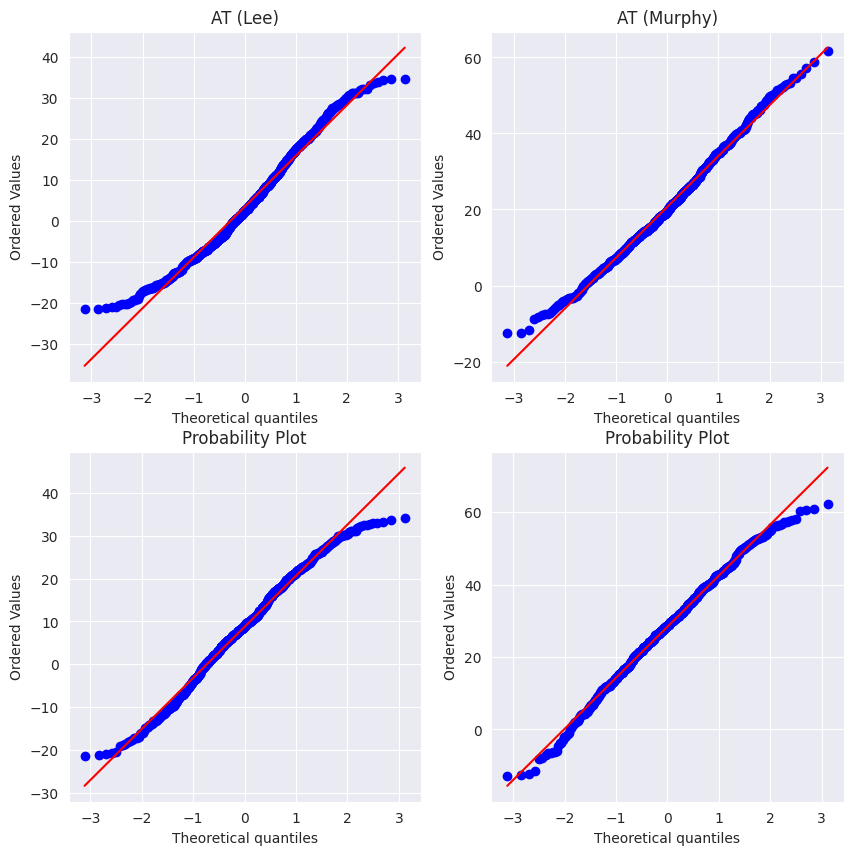

In [37]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
stats.probplot(at_lee_male.to_numpy(), plot=ax[0, 0])
ax[0, 0].set(title='AT (Lee)')
stats.probplot(at_lee_female.to_numpy(), plot=ax[1, 0])
stats.probplot(at_murphy_male.to_numpy(), plot=ax[0, 1])
ax[0, 1].set(title='AT (Murphy)')
stats.probplot(at_murphy_female.to_numpy(), plot=ax[1, 1])
plt.show()

**Plots show data are normally distributed**

In [38]:
stats.levene(at_lee_male, at_lee_female)

LeveneResult(statistic=2.4959449179543673, pvalue=0.11434296836538142)

In [39]:
stats.levene(at_murphy_male, at_murphy_female)

LeveneResult(statistic=1.3657631478217247, pvalue=0.24272006680327254)

**Can assume both to have equal variance**

In [40]:
stats.ttest_ind(at_lee_male.to_numpy(), at_lee_female.to_numpy(), equal_var=True)

TtestResult(statistic=-8.63812098363991, pvalue=1.3910959595802353e-17, df=1557.0)

In [41]:
stats.ttest_ind(at_murphy_male.to_numpy(), at_murphy_female.to_numpy(), equal_var=True)

TtestResult(statistic=-11.0064195081783, pvalue=3.472707442110766e-27, df=1557.0)

**-> There is a significant difference between male and female**

## Effect size

In [42]:
import numpy as np

In [43]:
def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

In [44]:
cohen_d(at_lee_male.to_numpy(), at_lee_female.to_numpy())

-0.4378015864533291

In [45]:
cohen_d(at_murphy_male.to_numpy(), at_murphy_female.to_numpy())

-0.5578328818243605

**Interpretation:**
- 0.2 < d < 0.5: small effect
- 0.5 < d < 0.8: medium effect
- 0.8 < d: strong effect

# TT as function of age

In [46]:
X = combined[['TT', 'Age']].copy()
X = X.dropna()
Y = X['TT']
X = X['Age'].to_numpy().reshape(-1, 1)

In [47]:
reg = linear_model.LinearRegression()
reg.fit(X, Y)
reg.coef_

array([-0.05717308])

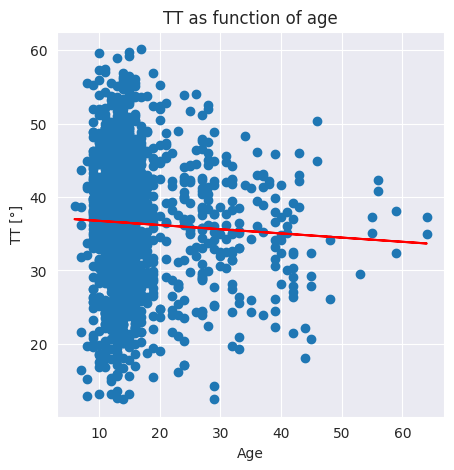

In [48]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X, Y)
ax.plot(X, reg.predict(X), 'r')
ax.set(title='TT as function of age', xlabel='Age', ylabel='TT [°]')
plt.show()

# TT as function of sex

In [49]:
data = combined[['TT', 'Sex']].copy()
data = data.dropna()

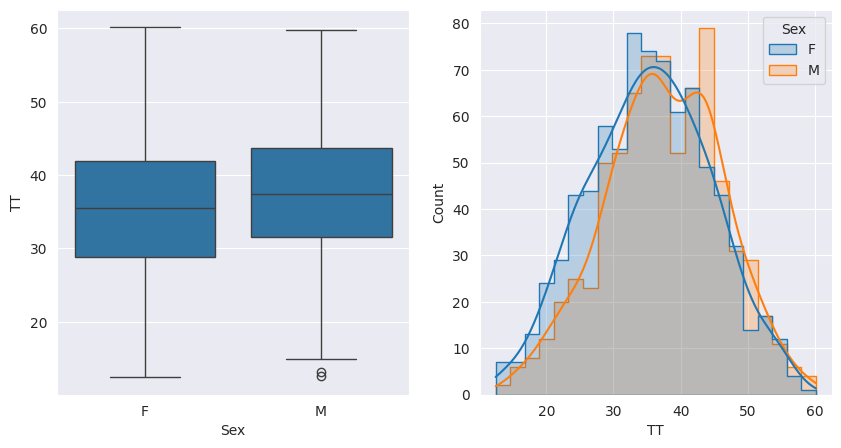

In [50]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
sns.boxplot(x='Sex', y='TT', data=data, ax=ax[0])
sns.histplot(x='TT', hue='Sex', kde=True, element='step', data=data, ax=ax[1])
plt.show()

In [51]:
lb = LabelBinarizer()
lb.fit(data['Sex'])
labels = lb.transform(data['Sex'])

In [52]:
pd.DataFrame(data={'Sex': data['Sex'], 'Label': labels.T[0]})

Sex  Label
Patient  Side            
PA000291 right   F      0
         left    F      0
PA000464 right   F      0
         left    F      0
PA000654 right   F      0
...             ..    ...
PA001031 left    F      0
PA000807 right   F      0
         left    F      0
PA000227 right   M      1
         left    M      1

[1551 rows x 2 columns]

In [53]:
stats.pointbiserialr(labels.T[0], data['TT'].to_numpy())  # wtf numpy

SignificanceResult(statistic=0.11490149857363252, pvalue=5.719025922511762e-06)

**Interpretation:** Positive coefficient means TT is higher for males (encoded as 1)

## Normality testing

In [54]:
tt_male, tt_female = data[data['Sex'] == 'M']['TT'], data[data['Sex'] == 'F']['TT']

In [55]:
stats.shapiro(tt_male.to_numpy())

ShapiroResult(statistic=0.9959894415063324, pvalue=0.051507888109421286)

In [56]:
stats.shapiro(tt_female.to_numpy())

ShapiroResult(statistic=0.9959132788830363, pvalue=0.03379242016828322)

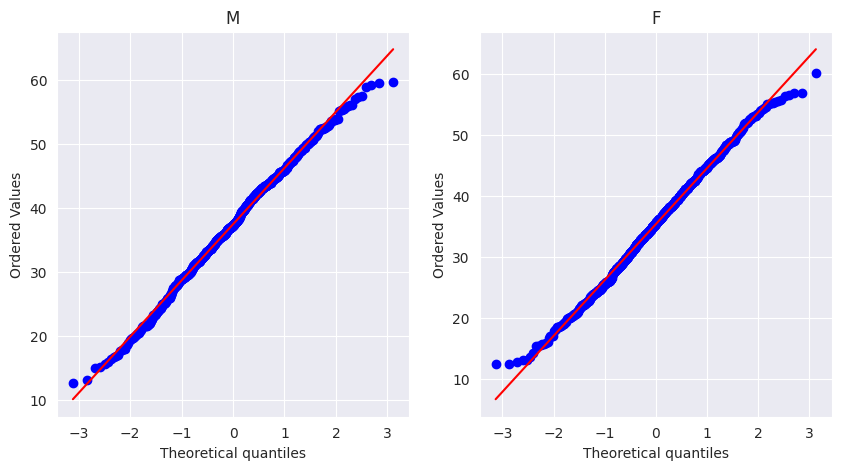

In [57]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
stats.probplot(tt_male.to_numpy(), plot=ax[0])
ax[0].set(title='M')
stats.probplot(tt_female.to_numpy(), plot=ax[1])
ax[1].set(title='F')
plt.show()

**Plots show data are normally distributed**

In [58]:
stats.levene(tt_male, at_lee_female)

LeveneResult(statistic=62.435562465009134, pvalue=5.284357589498211e-15)

In [59]:
stats.levene(tt_female, at_murphy_female)

LeveneResult(statistic=111.49953290509016, pvalue=3.2200493870097425e-25)

**Can assume both to not have equal variance**

In [60]:
stats.ttest_ind(tt_male.to_numpy(), tt_female.to_numpy(), equal_var=False)

TtestResult(statistic=4.5584742622576115, pvalue=5.557671031009658e-06, df=1548.027069770721)

**-> There is a significant difference between male and female**

## Effect size

In [61]:
cohen_d(tt_male.to_numpy(), tt_female.to_numpy())

0.23131103860364877

**Interpretation:**
- 0.2 < d < 0.5: small
effect
- 0.5 < d < 0.8: medium
effect
- 0.8 < d: strong
effect

# CCD as function of age

In [62]:
X = combined[['CCD (actual)', 'CCD (projected)', 'Age']].copy()
X = X.dropna()
Y_1 = X['CCD (actual)']
Y_2 = X['CCD (projected)']
X = X['Age'].to_numpy().reshape(-1, 1)

In [63]:
reg_1 = linear_model.LinearRegression()
reg_1.fit(X, Y_1)
reg_1.coef_

array([0.26045171])

In [64]:
stats.pearsonr(X.flatten(), Y_1)

PearsonRResult(statistic=0.11179143322094134, pvalue=4.756595253471878e-06)

In [65]:
reg_2 = linear_model.LinearRegression()
reg_2.fit(X, Y_2)
reg_2.coef_

array([0.03437839])

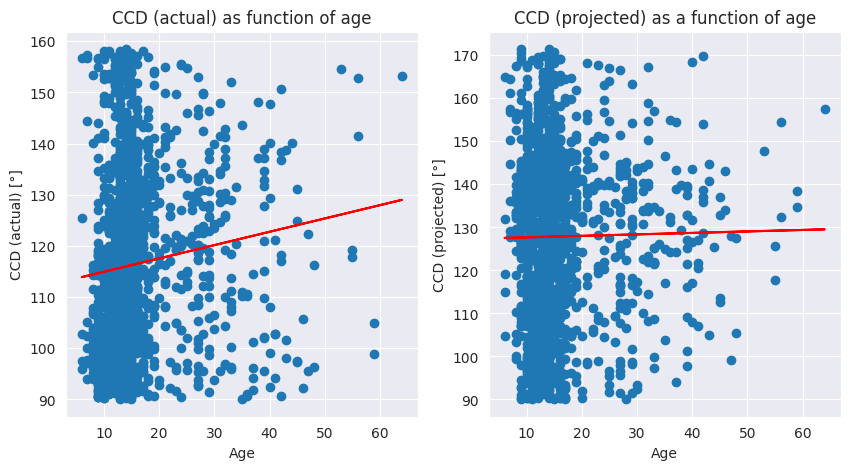

In [66]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=False)
ax[0].scatter(X, Y_1)
ax[0].plot(X, reg_1.predict(X), 'r')
ax[0].set(title='CCD (actual) as function of age', xlabel='Age', ylabel='CCD (actual) [°]')
ax[1].scatter(X, Y_2)
ax[1].plot(X, reg_2.predict(X), 'r')
ax[1].set(title='CCD (projected) as a function of age', xlabel='Age', ylabel='CCD (projected) [°]')
plt.show()

# CCD as function of Sex

In [67]:
data = combined[['CCD (actual)', 'CCD (projected)', 'Sex']].copy()
data = data.dropna()

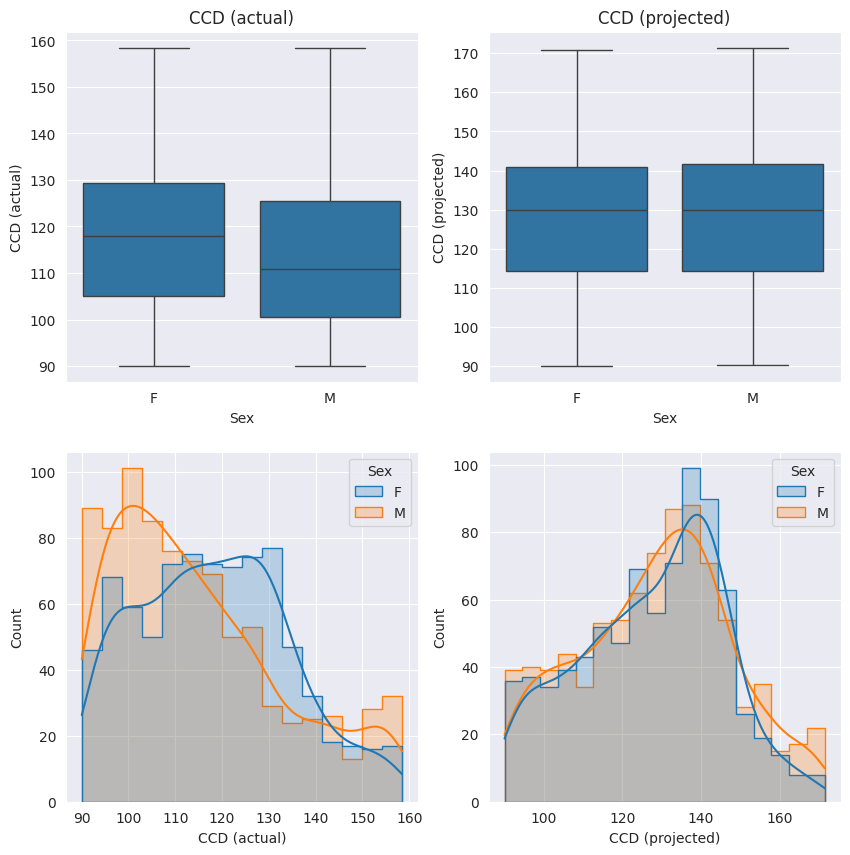

In [68]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
sns.boxplot(x='Sex', y='CCD (actual)', data=data, ax=ax[0, 0])
ax[0][0].set(title='CCD (actual)')
sns.boxplot(x='Sex', y='CCD (projected)', data=data, ax=ax[0, 1])
ax[0][1].set(title='CCD (projected)')
sns.histplot(x='CCD (actual)', hue='Sex', kde=True, element='step', data=data, ax=ax[1, 0])
sns.histplot(x='CCD (projected)', hue='Sex', kde=True, element='step', data=data, ax=ax[1, 1])
plt.show()

In [69]:
lb = LabelBinarizer()
lb.fit(data['Sex'])
labels = lb.transform(data['Sex'])

In [70]:
pd.DataFrame(data={'Sex': data['Sex'], 'Label': labels.T[0]})

Sex  Label
Patient  Side            
PA000291 right   F      0
         left    F      0
PA000464 left    F      0
PA000654 right   F      0
         left    F      0
...             ..    ...
PA001031 left    F      0
PA000807 right   F      0
         left    F      0
PA000227 right   M      1
         left    M      1

[1667 rows x 2 columns]

In [71]:
stats.pointbiserialr(labels.T[0], data['CCD (actual)'].to_numpy())  # wtf numpy

SignificanceResult(statistic=-0.09926051253687584, pvalue=4.913838121951878e-05)

**Interpretation:** Negative coefficient means CCD is higher for females (encoded as 0)

In [72]:
stats.pointbiserialr(labels.T[0], data['CCD (projected)'].to_numpy())  # wtf numpy

SignificanceResult(statistic=0.021331053752467875, pvalue=0.38409854169688534)

**Interpretation:** Positive coefficient means CCD is higher for males (encoded as 1)

## Normality testing

In [73]:
ccd_actual_male, ccd_actual_female = data[data['Sex'] == 'M']['CCD (actual)'], data[data['Sex'] == 'F']['CCD (actual)']
ccd_projected_male, ccd_projected_female = data[data['Sex'] == 'M']['CCD (projected)'], data[data['Sex'] == 'F']['CCD (projected)']

In [74]:
stats.shapiro(ccd_actual_male.to_numpy())

ShapiroResult(statistic=0.9256309719387638, pvalue=3.746240913570797e-20)

In [75]:
stats.shapiro(ccd_actual_female.to_numpy())

ShapiroResult(statistic=0.9774305976611203, pvalue=7.168300457397769e-10)

In [76]:
stats.shapiro(ccd_projected_male.to_numpy())

ShapiroResult(statistic=0.9831258447493052, pvalue=2.2422273942900892e-08)

In [77]:
stats.shapiro(ccd_projected_female.to_numpy())

ShapiroResult(statistic=0.976520390844183, pvalue=3.9055747581136364e-10)

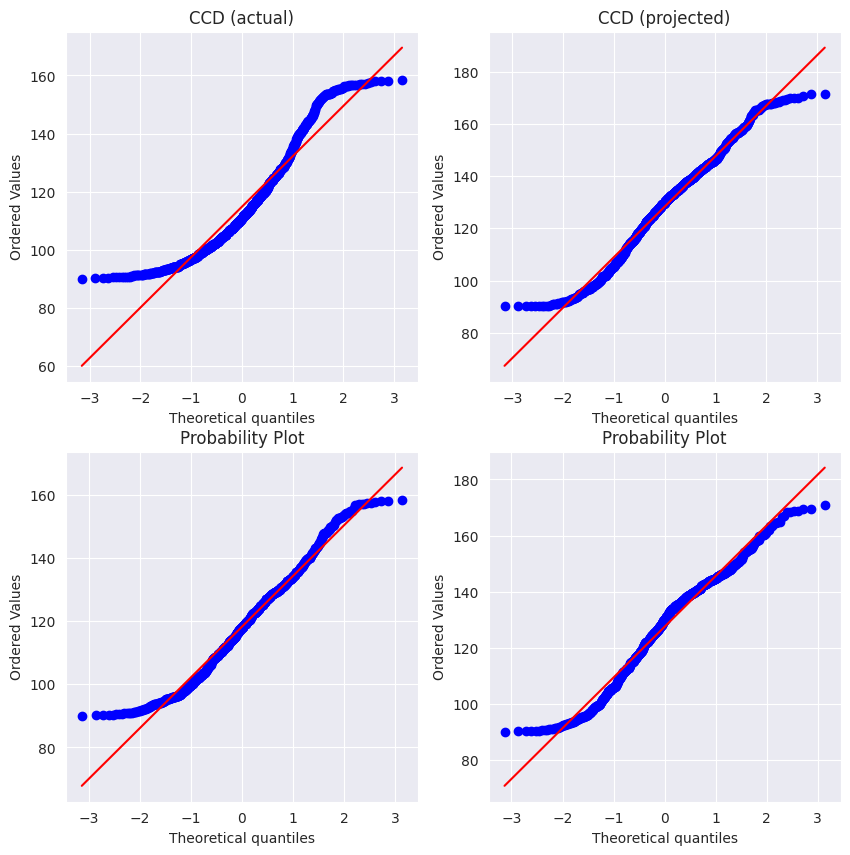

In [78]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
stats.probplot(ccd_actual_male.to_numpy(), plot=ax[0, 0])
ax[0, 0].set(title='CCD (actual)')
stats.probplot(ccd_actual_female.to_numpy(), plot=ax[1, 0])
stats.probplot(ccd_projected_male.to_numpy(), plot=ax[0, 1])
ax[0, 1].set(title='CCD (projected)')
stats.probplot(ccd_projected_female.to_numpy(), plot=ax[1, 1])
plt.show()

**Plots show data are not normally distributed**

In [79]:
stats.mannwhitneyu(ccd_actual_male, ccd_actual_female, alternative='two-sided')

MannwhitneyuResult(statistic=295407.0, pvalue=1.4166131809580216e-07)

In [80]:
stats.mannwhitneyu(ccd_projected_male, ccd_projected_female, alternative='two-sided')

MannwhitneyuResult(statistic=351478.0, pvalue=0.6564552225233862)

**There is only a significant difference for the actual CCD**

## Effect size

In [81]:
%load_ext rpy2.ipython

In [82]:
%%R
library(effectsize)

In addition: Warning message:
In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library ‘/usr/local/lib/R/site-library’ contains no packages


In [83]:
tmp1, tmp2 = ccd_actual_male.to_numpy(), ccd_actual_female.to_numpy()

In [84]:
%%R -i tmp1 -i tmp2
ccd_actual_male <- tmp1
ccd_actual_female <- tmp2

In [85]:
%%R
rb <- rank_biserial(ccd_actual_male, ccd_actual_female)
print(interpret(rb, rules='funder2019'))

r (rank biserial) |         95% CI | Interpretation
---------------------------------------------------
-0.15             | [-0.20, -0.09] |          small

- Interpretation rule: funder2019

In [86]:
tmp1, tmp2 = ccd_projected_male.to_numpy(), ccd_projected_female.to_numpy()

In [87]:
%%R -i tmp1 -i tmp2
ccd_projected_male <- tmp1
ccd_projected_female <- tmp2


In [88]:
%%R
rb <- rank_biserial(ccd_projected_male, ccd_projected_female)
print(interpret(rb, rules='funder2019'))

r (rank biserial) |        95% CI | Interpretation
--------------------------------------------------
0.01              | [-0.04, 0.07] |           tiny

- Interpretation rule: funder2019

# KRA as function of age

In [89]:
X = combined[['KRA', 'Age']].copy()
X = X.dropna()
Y = X['KRA']
X = X['Age'].to_numpy().reshape(-1, 1)

In [90]:
reg = linear_model.LinearRegression()
reg.fit(X, Y)
reg.coef_

array([0.05530526])

In [91]:
stats.pearsonr(X.flatten(), Y)

PearsonRResult(statistic=0.10584166639714859, pvalue=0.00013408864361617097)

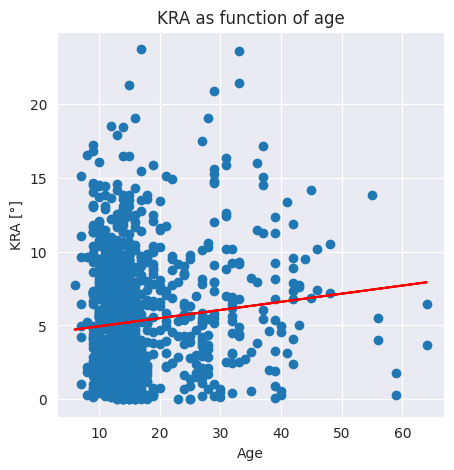

In [92]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X, Y)
ax.plot(X, reg.predict(X), 'r')
ax.set(title='KRA as function of age', xlabel='Age', ylabel='KRA [°]')
plt.show()

# KRA as function of sex

In [93]:
data = combined[['KRA', 'Sex']].copy()
data = data.dropna()

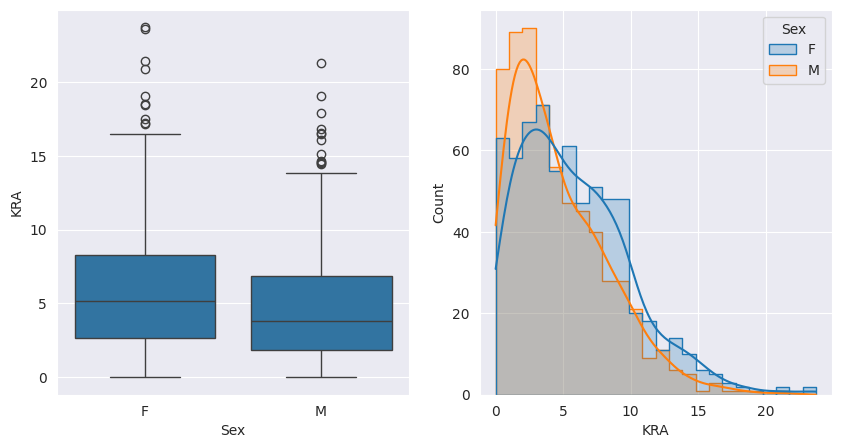

In [94]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
sns.boxplot(x='Sex', y='KRA', data=data, ax=ax[0])
sns.histplot(x='KRA', hue='Sex', kde=True, element='step', data=data, ax=ax[1])
plt.show()

In [95]:
lb = LabelBinarizer()
lb.fit(data['Sex'])
labels = lb.transform(data['Sex'])
pd.DataFrame(data={'Sex': data['Sex'], 'Label': labels.T[0]})

Sex  Label
Patient  Side            
PA000291 left    F      0
PA000464 left    F      0
PA000654 right   F      0
         left    F      0
PA000926 right   M      1
...             ..    ...
PA001031 right   F      0
         left    F      0
PA000807 left    F      0
PA000227 right   M      1
         left    M      1

[1297 rows x 2 columns]

In [96]:
stats.pointbiserialr(labels.T[0], data['KRA'].to_numpy())  # wtf numpy

SignificanceResult(statistic=-0.14672082196328473, pvalue=1.1105376124999152e-07)

**Interpretation:** Negative coefficient means TT is higher for females (encoded as 0)

## Normality testing

In [97]:
kra_male, kra_female = data[data['Sex'] == 'M']['KRA'], data[data['Sex'] == 'F']['KRA']

In [98]:
stats.shapiro(kra_male.to_numpy())

ShapiroResult(statistic=0.917843845463935, pvalue=4.577470058551824e-18)

In [99]:
stats.shapiro(kra_female.to_numpy())

ShapiroResult(statistic=0.9386459431443309, pvalue=6.813515986129013e-16)

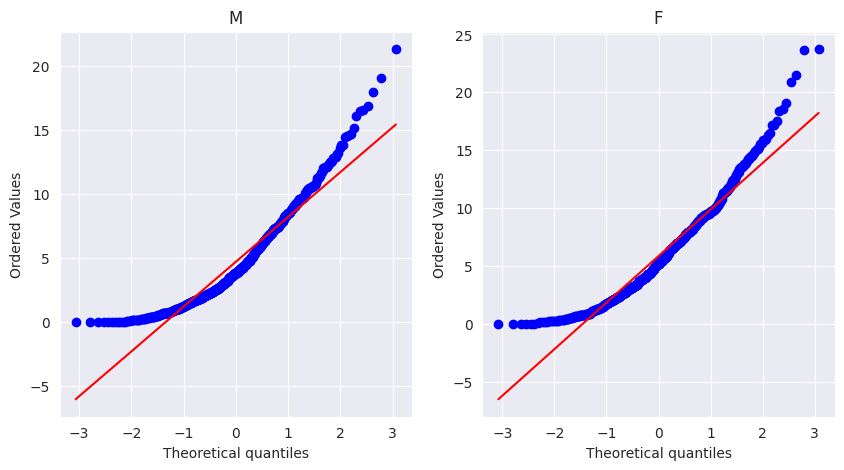

In [100]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
stats.probplot(kra_male.to_numpy(), plot=ax[0])
ax[0].set(title='M')
stats.probplot(kra_female.to_numpy(), plot=ax[1])
ax[1].set(title='F')
plt.show()

**Plots show data are not normally distributed**

In [101]:
stats.mannwhitneyu(kra_male, kra_female, alternative='two-sided')

MannwhitneyuResult(statistic=174619.0, pvalue=1.3463458438670806e-07)

## Effect size

In [102]:
tmp1, tmp2 = kra_male.to_numpy(), kra_female.to_numpy()

In [103]:
%%R -i tmp1 -i tmp2
kra_male <- tmp1
kra_female <- tmp2

In [104]:
%%R
rb <- rank_biserial(kra_male, kra_female)
print(interpret(rb, rules='funder2019'))

r (rank biserial) |         95% CI | Interpretation
---------------------------------------------------
-0.17             | [-0.23, -0.11] |          small

- Interpretation rule: funder2019

# Leg Length as function of age

In [161]:
X = combined[['LL', 'Age']].copy()
X = X.dropna()
Y = X['LL']
X = X['Age'].to_numpy().reshape(-1, 1)

In [162]:
reg = linear_model.LinearRegression()
reg.fit(X, Y)
reg.coef_

array([3.18496501])

In [163]:
stats.pearsonr(X.flatten(), Y)

PearsonRResult(statistic=0.2787859837590348, pvalue=3.3258387861012723e-35)

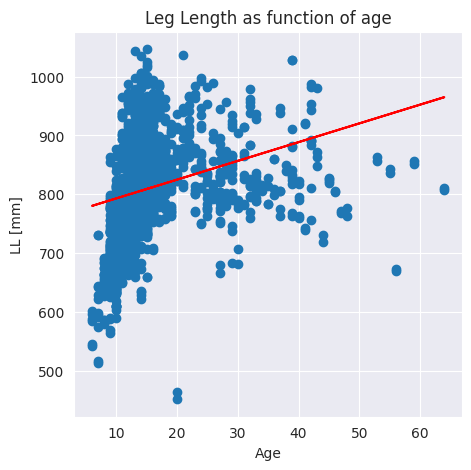

In [164]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X, Y)
ax.plot(X, reg.predict(X), 'r')
ax.set(title='Leg Length as function of age', xlabel='Age', ylabel='LL [mm]')
plt.show()

# Leg Length as function of sex

In [165]:
data = combined[['LL', 'Sex']].copy()
data = data.dropna()

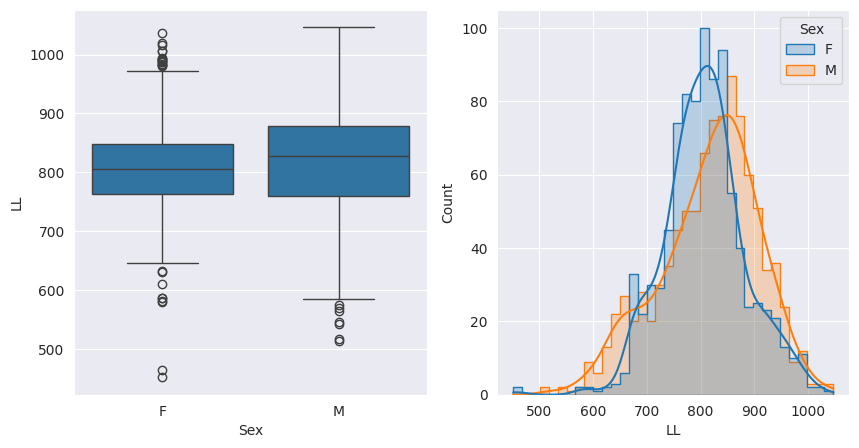

In [169]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
sns.boxplot(x='Sex', y='LL', data=data, ax=ax[0])
sns.histplot(x='LL', hue='Sex', kde=True, element='step', data=data, ax=ax[1])
plt.show()

In [170]:
lb = LabelBinarizer()
lb.fit(data['Sex'])
labels = lb.transform(data['Sex'])
pd.DataFrame(data={'Sex': data['Sex'], 'Label': labels.T[0]})

Sex  Label
Patient  Side            
PA000291 right   F      0
         left    F      0
PA000464 right   F      0
         left    F      0
PA000654 right   F      0
...             ..    ...
PA001031 left    F      0
PA000807 right   F      0
         left    F      0
PA000227 right   M      1
         left    M      1

[1897 rows x 2 columns]

In [172]:
stats.pointbiserialr(labels.T[0], data['LL'].to_numpy())  # wtf numpy

SignificanceResult(statistic=0.05138172549721677, pvalue=0.025226806565746687)

**Interpretation:** Positive coefficient means LL is higher for males (encoded as 1)

## Normality testing

In [173]:
ll_male, ll_female = data[data['Sex'] == 'M']['LL'], data[data['Sex'] == 'F']['LL']

In [174]:
stats.shapiro(ll_male.to_numpy())

ShapiroResult(statistic=0.9813010251091795, pvalue=7.135627939042497e-10)

In [175]:
stats.shapiro(ll_female.to_numpy())

ShapiroResult(statistic=0.9880019106264042, pvalue=7.649529488555107e-07)

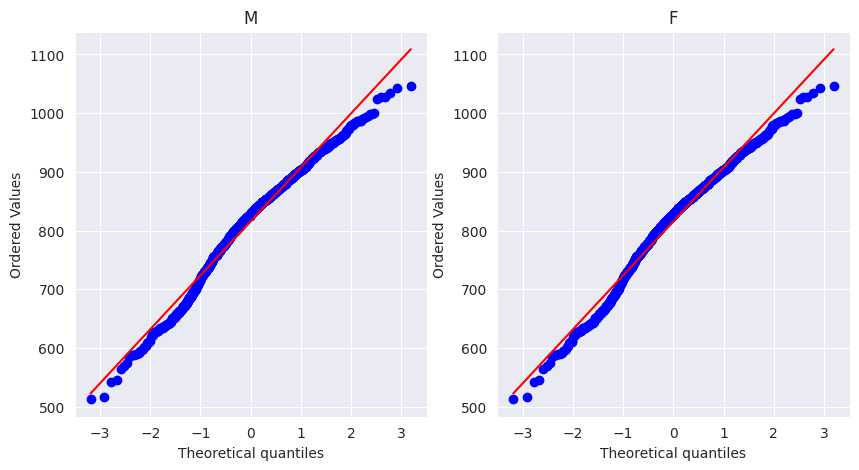

In [176]:

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
stats.probplot(kra_male.to_numpy(), plot=ax[0])
ax[0].set(title='M')
stats.probplot(kra_female.to_numpy(), plot=ax[1])
ax[1].set(title='F')
plt.show()

**Plots show data are normally distributed**

In [178]:
stats.levene(ll_male, ll_female)

LeveneResult(statistic=38.3657748624162, pvalue=7.174655866696027e-10)

**Can assume both to not have equal variance**

In [179]:
stats.ttest_ind(ll_male.to_numpy(), ll_female.to_numpy(), equal_var=False)

TtestResult(statistic=2.253284172320228, pvalue=0.024357456524436574, df=1857.3848266248674)

**-> There is a significant difference between male and female**

## Effect size

In [180]:
cohen_d(ll_male.to_numpy(), ll_female.to_numpy())

0.1028915728815178

**Interpretation:**
- 0.2 < d < 0.5: small
effect
- 0.5 < d < 0.8: medium
effect
- 0.8 < d: strong
effect

# AT as function of other factors

## AT (Lee)

In [265]:
data = combined[['AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'CCD (projected)', 'TT', 'KRA', 'LL']].copy()
data = data.dropna()
Y = data['AT (Lee)']
X = data[['AT (Murphy)', 'CCD (actual)', 'CCD (projected)', 'TT', 'KRA', 'LL']]

In [222]:
from sklearn.preprocessing import StandardScaler, PowerTransformer

In [223]:
scaler = StandardScaler()
X_1 = scaler.fit_transform(X, Y)
X_1

array([[-0.37898459, -0.35558852, -0.58254311,  1.07263527, -0.29495863,
         0.49570674],
       [-1.7835574 , -0.87650431, -1.42924842, -0.34718921,  0.48625859,
        -0.56237893],
       [-1.93772989, -1.25471523,  0.48105888, -0.3762483 ,  0.05405775,
        -0.57270329],
       ...,
       [-2.2447872 ,  0.60620623, -0.00520153,  0.16480884, -0.31356741,
         0.0270476 ],
       [-1.11115742, -1.30632319,  0.0509602 ,  0.00628205, -1.24859578,
         0.54854076],
       [-1.37448631, -1.23777525, -0.2985482 , -1.00275252, -1.23848516,
         0.61096036]])

In [224]:
transformer = PowerTransformer(method='yeo-johnson')
X_2 = transformer.fit_transform(X, Y)
X_2

array([[-3.46098683e-01, -2.57073775e-01, -5.80127539e-01,
         1.07800396e+00, -7.05212511e-02,  4.66139613e-01],
       [-1.86285490e+00, -8.72748060e-01, -1.43246756e+00,
        -3.61918771e-01,  6.69944295e-01, -6.00832344e-01],
       [-2.07581225e+00, -1.37773994e+00,  4.83372796e-01,
        -3.90788114e-01,  2.93455180e-01, -6.10727706e-01],
       ...,
       [-2.54065568e+00,  6.90580977e-01, -1.92561982e-03,
         1.50929685e-01, -9.19384905e-02, -1.93874592e-02],
       [-1.09925572e+00, -1.45099122e+00,  5.42011854e-02,
        -8.68597707e-03, -1.75554273e+00,  5.22168188e-01],
       [-1.38432893e+00, -1.35393581e+00, -2.95426446e-01,
        -1.00640982e+00, -1.72445693e+00,  5.88699929e-01]])

In [225]:
from sklearn.feature_selection import f_regression, r_regression

In [234]:
def pretty_print(x, y, var_names):
    f = f_regression(x, y)
    r = r_regression(x, y)
    table = pd.DataFrame(data = [r, f[0], f[1]], columns=var_names, index=pd.Index(['r value', 'f value', 'p value']))
    return table.T

In [235]:
pretty_print(X_1, Y, X.columns)

,r value,f value,p value
AT (Murphy),0.852998,2639.098803,2.890237e-281
CCD (actual),0.030722,0.933420,3.342123e-01
CCD (projected),-0.002048,0.004144,9.486834e-01
TT,0.097057,9.395579,2.234169e-03
KRA,0.275566,81.190674,1.036867e-18
LL,-0.344239,132.817204,6.369901e-29


In [236]:
pretty_print(X_2, Y, X.columns)

,r value,f value,p value
AT (Murphy),0.850810,2590.116272,2.393784e-278
CCD (actual),0.029836,0.880281,3.483541e-01
CCD (projected),-0.002391,0.005647,9.401147e-01
TT,0.098214,9.623071,1.976032e-03
KRA,0.270825,78.202059,4.203351e-18
LL,-0.334704,124.645817,2.432112e-27


In [272]:
reg_1, reg_2 = linear_model.LinearRegression(), linear_model.LinearRegression()
X_1 = data['KRA'].to_numpy().reshape(-1, 1)
X_2 = data['LL'].to_numpy().reshape(-1, 1)
reg_1.fit(X_1, Y)
reg_2.fit(X_2, Y)

LinearRegression()

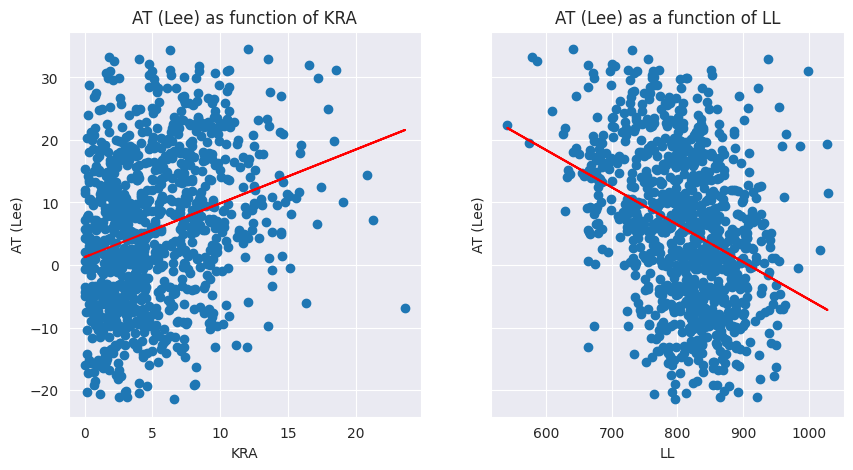

In [274]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=False, sharey=True)
ax[0].scatter(X_1, Y)
ax[0].plot(X_1, reg_1.predict(X_1), 'r')
ax[0].set(title='AT (Lee) as function of KRA', xlabel='KRA', ylabel='AT (Lee)')
ax[1].scatter(X_2, Y)
ax[1].plot(X_2, reg_2.predict(X_2), 'r')
ax[1].set(title='AT (Lee) as a function of LL', xlabel='LL', ylabel='AT (Lee)')
plt.show()

## AT (Murphy)

In [275]:
data = combined[['AT (Murphy)', 'AT (Lee)', 'CCD (actual)', 'CCD (projected)', 'TT', 'KRA', 'LL']].copy()
data = data.dropna()
Y = data['AT (Murphy)']
X = data[['AT (Lee)', 'CCD (actual)', 'CCD (projected)', 'TT', 'KRA', 'LL']]

In [242]:
X = transformer.fit_transform(X, Y)

In [243]:
pretty_print(X, Y, data.columns[1:])

,r value,f value,p value
AT (Lee),0.852130,2619.489789,4.211013e-280
CCD (actual),0.114229,13.062204,3.165131e-04
CCD (projected),-0.031216,0.963686,3.265004e-01
TT,0.072638,5.240550,2.227652e-02
KRA,0.238372,59.521404,2.948846e-14
LL,-0.266902,75.780023,1.311245e-17


In [276]:
reg_1, reg_2 = linear_model.LinearRegression(), linear_model.LinearRegression()
X_1 = data['KRA'].to_numpy().reshape(-1, 1)
X_2 = data['LL'].to_numpy().reshape(-1, 1)
reg_1.fit(X_1, Y)
reg_2.fit(X_2, Y)

LinearRegression()

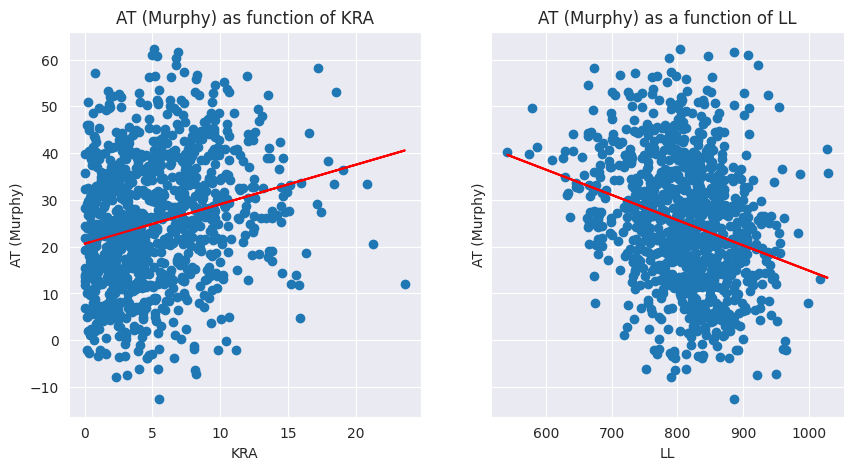

In [277]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=False, sharey=True)
ax[0].scatter(X_1, Y)
ax[0].plot(X_1, reg_1.predict(X_1), 'r')
ax[0].set(title='AT (Murphy) as function of KRA', xlabel='KRA', ylabel='AT (Murphy)')
ax[1].scatter(X_2, Y)
ax[1].plot(X_2, reg_2.predict(X_2), 'r')
ax[1].set(title='AT (Murphy) as a function of LL', xlabel='LL', ylabel='AT (Murphy)')
plt.show()

# TT as function of other factors

In [278]:
data = combined[['TT', 'AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'CCD (projected)', 'KRA', 'LL']].copy()
data = data.dropna()
Y = data['TT']
X = data[['AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'CCD (projected)', 'KRA', 'LL']]

In [245]:
X = transformer.fit_transform(X, Y)

In [246]:
pretty_print(X, Y, data.columns[1:])

,r value,f value,p value
AT (Lee),0.097779,9.537160,0.002070
AT (Murphy),0.076250,5.777908,0.016412
CCD (actual),-0.041475,1.702464,0.192270
CCD (projected),0.004037,0.016103,0.899047
KRA,-0.037251,1.372924,0.241593
LL,0.012679,0.158851,0.690302


In [279]:
reg_1, reg_2 = linear_model.LinearRegression(), linear_model.LinearRegression()
X_1 = data['AT (Lee)'].to_numpy().reshape(-1, 1)
X_2 = data['AT (Murphy)'].to_numpy().reshape(-1, 1)
reg_1.fit(X_1, Y)
reg_2.fit(X_2, Y)

LinearRegression()

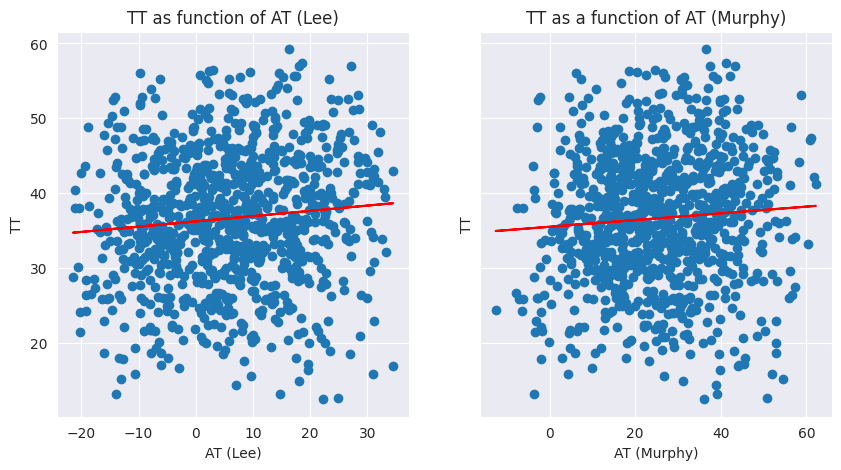

In [280]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=False, sharey=True)
ax[0].scatter(X_1, Y)
ax[0].plot(X_1, reg_1.predict(X_1), 'r')
ax[0].set(title='TT as function of AT (Lee)', xlabel='AT (Lee)', ylabel='TT')
ax[1].scatter(X_2, Y)
ax[1].plot(X_2, reg_2.predict(X_2), 'r')
ax[1].set(title='TT as a function of AT (Murphy)', xlabel='AT (Murphy)', ylabel='TT')
plt.show()

# CCD as function of other factors

## CCD (actual)

In [281]:
data = combined[['CCD (actual)', 'AT (Lee)', 'AT (Murphy)', 'CCD (projected)', 'TT', 'KRA', 'LL']].copy()
data = data.dropna()
Y = data['CCD (actual)']
X = data[['AT (Lee)', 'AT (Murphy)', 'CCD (projected)', 'TT', 'KRA', 'LL']]

In [248]:
X = transformer.fit_transform(X, Y)

In [249]:
pretty_print(X, Y, data.columns[1:])

,r value,f value,p value
AT (Lee),0.032745,1.060500,3.033532e-01
AT (Murphy),0.113475,12.887991,3.469559e-04
CCD (projected),0.366462,153.265375,7.917161e-33
TT,-0.041935,1.740544,1.873756e-01
KRA,0.008161,0.065803,7.976022e-01
LL,0.086154,7.388276,6.679968e-03


In [282]:
reg_1, reg_2 = linear_model.LinearRegression(), linear_model.LinearRegression()
X_1 = data['AT (Murphy)'].to_numpy().reshape(-1, 1)
X_2 = data['LL'].to_numpy().reshape(-1, 1)
reg_1.fit(X_1, Y)
reg_2.fit(X_2, Y)

LinearRegression()

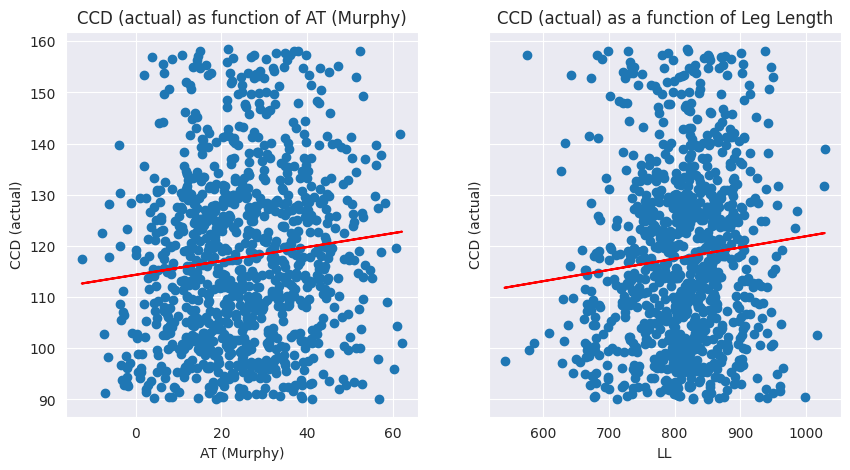

In [283]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=False, sharey=True)
ax[0].scatter(X_1, Y)
ax[0].plot(X_1, reg_1.predict(X_1), 'r')
ax[0].set(title='CCD (actual) as function of AT (Murphy)', xlabel='AT (Murphy)', ylabel='CCD (actual)')
ax[1].scatter(X_2, Y)
ax[1].plot(X_2, reg_2.predict(X_2), 'r')
ax[1].set(title='CCD (actual) as a function of Leg Length', xlabel='LL', ylabel='CCD (actual)')
plt.show()

## CCD (projected)

In [284]:
data = combined[['CCD (projected)', 'AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'TT', 'KRA', 'LL']].copy()
data = data.dropna()
Y = data['CCD (projected)']
X = data[['AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'TT', 'KRA', 'LL']]

In [251]:
X = transformer.fit_transform(X, Y)

In [252]:
pretty_print(X, Y, data.columns[1:])

,r value,f value,p value
AT (Lee),-0.001467,0.002125,9.632394e-01
AT (Murphy),-0.027582,0.752183,3.859966e-01
CCD (actual),0.313341,107.565638,5.408215e-24
TT,0.003288,0.010679,9.177145e-01
KRA,-0.018445,0.336249,5.621346e-01
LL,0.031513,0.982136,3.219148e-01


# KRA as function of other factors

In [288]:
data = combined[['KRA', 'AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'CCD (projected)', 'TT', 'LL']].copy()
data = data.dropna()
Y = data['KRA']
X = data[['AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'CCD (projected)', 'TT', 'LL']]

In [256]:
X = transformer.fit_transform(X, Y)

In [257]:
pretty_print(X, Y, data.columns[1:])

,r value,f value,p value
AT (Lee),0.275202,80.959132,1.155441e-18
AT (Murphy),0.233888,57.174894,9.093845e-14
CCD (actual),0.016833,0.280024,5.968046e-01
CCD (projected),-0.021910,0.474522,4.910759e-01
TT,-0.039536,1.546731,2.139138e-01
LL,-0.095148,9.026224,2.728461e-03


In [289]:
reg_1, reg_2, reg_3 = linear_model.LinearRegression(), linear_model.LinearRegression(), linear_model.LinearRegression()
X_1 = data['AT (Lee)'].to_numpy().reshape(-1, 1)
X_2 = data['AT (Murphy)'].to_numpy().reshape(-1, 1)
X_3 = data['LL'].to_numpy().reshape(-1, 1)
reg_1.fit(X_1, Y)
reg_2.fit(X_2, Y)
reg_3.fit(X_3, Y)

LinearRegression()

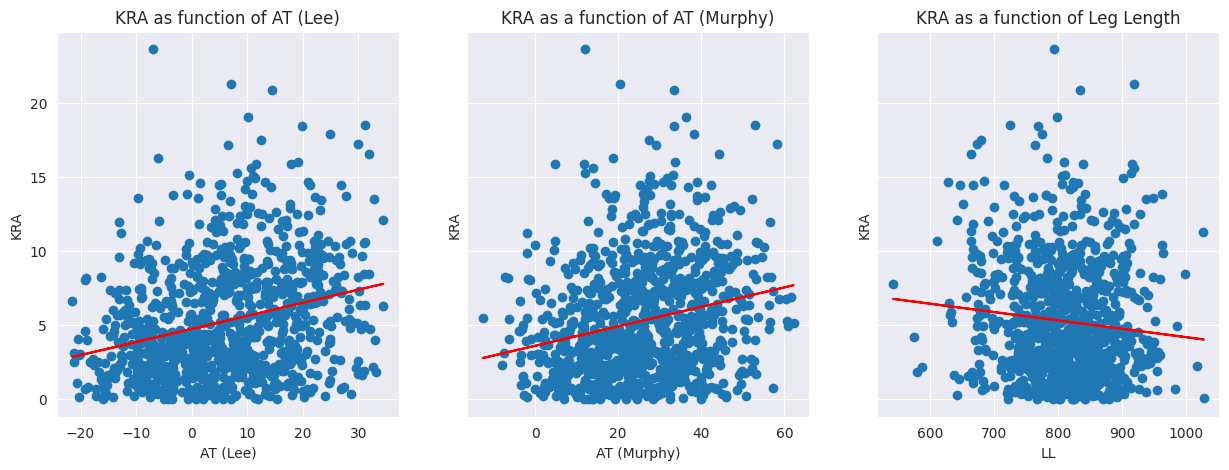

In [291]:
fig, ax = plt.subplots(ncols=3, figsize=(15, 5), sharex=False, sharey=True)
ax[0].scatter(X_1, Y)
ax[0].plot(X_1, reg_1.predict(X_1), 'r')
ax[0].set(title='KRA as function of AT (Lee)', xlabel='AT (Lee)', ylabel='KRA')
ax[1].scatter(X_2, Y)
ax[1].plot(X_2, reg_2.predict(X_2), 'r')
ax[1].set(title='KRA as a function of AT (Murphy)', xlabel='AT (Murphy)', ylabel='KRA')
ax[2].scatter(X_3, Y)
ax[2].plot(X_3, reg_3.predict(X_3), 'r')
ax[2].set(title='KRA as a function of Leg Length', xlabel='LL', ylabel='KRA')
plt.show()

# Leg Length as function of other factors

In [292]:
data = combined[['LL', 'AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'CCD (projected)', 'TT', 'KRA']].copy()
data = data.dropna()
Y = data['LL']
X = data[['AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'CCD (projected)', 'TT', 'KRA']]

In [262]:
X = transformer.fit_transform(X, Y)

In [263]:
pretty_print(X, Y, data.columns[1:])

,r value,f value,p value
AT (Lee),-0.341571,130.495953,1.787470e-28
AT (Murphy),-0.270834,78.207489,4.192658e-18
CCD (actual),0.093295,8.675052,3.301598e-03
CCD (projected),0.031471,0.979537,3.225554e-01
TT,0.011204,0.124045,7.247630e-01
KRA,-0.103128,10.620781,1.156387e-03


In [293]:
reg_1, reg_2, reg_3 = linear_model.LinearRegression(), linear_model.LinearRegression(), linear_model.LinearRegression()
X_1 = data['AT (Lee)'].to_numpy().reshape(-1, 1)
X_2 = data['AT (Murphy)'].to_numpy().reshape(-1, 1)
X_3 = data['KRA'].to_numpy().reshape(-1, 1)
reg_1.fit(X_1, Y)
reg_2.fit(X_2, Y)
reg_3.fit(X_3, Y)

LinearRegression()

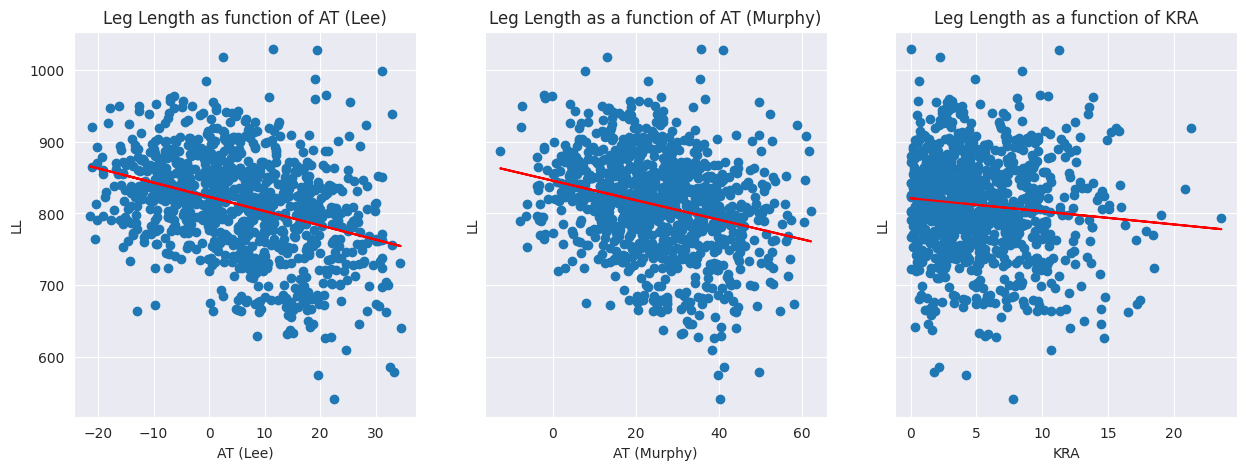

In [294]:
fig, ax = plt.subplots(ncols=3, figsize=(15, 5), sharex=False, sharey=True)
ax[0].scatter(X_1, Y)
ax[0].plot(X_1, reg_1.predict(X_1), 'r')
ax[0].set(title='Leg Length as function of AT (Lee)', xlabel='AT (Lee)', ylabel='LL')
ax[1].scatter(X_2, Y)
ax[1].plot(X_2, reg_2.predict(X_2), 'r')
ax[1].set(title='Leg Length as a function of AT (Murphy)', xlabel='AT (Murphy)', ylabel='LL')
ax[2].scatter(X_3, Y)
ax[2].plot(X_3, reg_3.predict(X_3), 'r')
ax[2].set(title='Leg Length as a function of KRA', xlabel='KRA', ylabel='LL')
plt.show()